![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)


# Zeitreihen

## **Aufgabe: Vorbereitung der Wetterdaten für die Zeitreihenanalyse**  

### **Einlesen und Vorverarbeitung der Wetterdaten**  
Bereite die Wetterdaten für die Zeitreihenanalyse vor, indem du das Datum korrekt formatierst und irrelevante Daten ausschließt.

#### **Aufgaben:**  
1. **Lade den Datensatz** `wetter.xlsx` in einen DataFrame.  
2. **Konvertiere das Datumsformat** in eine für Zeitreihen geeignete Form:  
   - Die Spalte `MESS_DATUM` liegt vermutlich als Ganzzahl vor (`YYYYMMDDHH`-Format).  
   - Wandle sie mit `pd.to_datetime()` in ein korrektes `datetime`-Format um.  
3. **Filtern der Daten**:  
   - Behalte nur Werte ab dem Jahr **1980** für die Analyse.  
   - Prüfe anschließend, ob die Filterung erfolgreich war, indem du das früheste und späteste Datum im Datensatz ausgibst.  
4. **Schaue dir die Daten an**:  
   - Verwende die `display()` Funktion 
#### **Hinweise:**  
- Falls der Datensatz Stundenwerte enthält (`%Y%m%d%H`), wird er nach Stunden aufgelöst. Falls eine aggregierte Betrachtung nötig ist, kann später eine Resampling-Methode (`df.resample()`) verwendet werden.  
- Falls das Datum nur Tageswerte enthält (`%Y%m%d`), kann die Konvertierung mit `format='%Y%m%d'` erfolgen.  
- Nutze `df['MESS_DATUM'].min(), df['MESS_DATUM'].max()`, um zu prüfen, ob die Filterung korrekt angewendet wurde.  



In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Daten einlesen
file_path = "wetter.xlsx"
df = pd.read_excel(file_path)
df.head()

,STATIONS_ID,MESS_DATUM,QN_4,TT_TER,RF_TER
0,1,1937010107,5,-0.4,-999.0
1,1,1937010114,5,1.6,-999.0
2,1,1937010121,5,-1.6,-999.0
3,1,1937010207,5,-2.8,-999.0
4,1,1937010214,5,4.4,-999.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52044 entries, 0 to 52043
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   STATIONS_ID  52044 non-null  int64  
 1   MESS_DATUM   52044 non-null  int64  
 2   QN_4         52044 non-null  int64  
 3   TT_TER       52044 non-null  float64
 4   RF_TER       52044 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 2.0 MB


In [5]:
# 2. Datumskonvertierung
df["MESS_DATUM"] = pd.to_datetime(df["MESS_DATUM"], format="%Y%m%d%H")

# Daten filtern: Nur Werte ab dem Jahr 1980 behalten
df = df[df["MESS_DATUM"].dt.year >= 1980]

# Bestätigen, dass die Filterung geklappt hat
df["MESS_DATUM"].min(), df["MESS_DATUM"].max()

(Timestamp('1980-01-01 07:00:00'), Timestamp('1986-06-30 21:00:00'))

In [6]:
display(df)

,STATIONS_ID,MESS_DATUM,QN_4,TT_TER,RF_TER
44925,1,1980-01-01 07:00:00,5,-6.4,92.0
44926,1,1980-01-01 14:00:00,5,-1.0,74.0
44927,1,1980-01-01 21:00:00,5,-2.4,85.0
44928,1,1980-01-02 07:00:00,5,-6.8,89.0
44929,1,1980-01-02 14:00:00,5,-1.0,73.0
...,...,...,...,...,...
52039,1,1986-06-29 14:00:00,10,28.6,36.0
52040,1,1986-06-29 21:00:00,10,19.7,60.0
52041,1,1986-06-30 07:00:00,10,17.8,75.0
52042,1,1986-06-30 14:00:00,10,24.6,41.0



## **Aufgabe: Explorative Datenanalyse der Temperaturwerte**  

### **Statistische Analyse und Visualisierung der Temperaturverteilung**  
Untersuche die Temperaturwerte (`TT_TER`) im Datensatz mithilfe statistischer Kennzahlen und Visualisierungen.

#### **Aufgaben:**  
1. Berechne die **deskriptiven Statistiken** für die Temperaturwerte:  
   - Mittelwert, Median, Minimum, Maximum, Standardabweichung, Quartile  
   - Verwende `df.describe()`, um diese Werte auszugeben.  
2. Erstelle eine **Histogramm-Visualisierung** der Temperaturverteilung:  
   - Verwende ein Histogramm mit `bins=30`, um die Verteilung der Werte darzustellen.  
   - Ergänze eine **Dichtekurve (KDE)**, um eine glatte Abschätzung der Verteilung zu erhalten.  
   - Beschrifte die Achsen und setze einen aussagekräftigen Titel.  

#### **Hinweise:**  
- `df.describe()` gibt dir einen schnellen Überblick über zentrale Tendenzen und Streuung der Temperaturwerte.  
- Falls du die Daten vor der Analyse bereinigt hast (z. B. durch Entfernung von Ausreißern), überprüfe, wie sich die Statistik verändert hat.  
- Das **Histogramm mit KDE** (`sns.histplot(df['TT_TER'], bins=30, kde=True)`) hilft dir, die Verteilung der Temperaturwerte besser zu interpretieren.  
- Falls das Histogramm stark asymmetrisch oder mehrgipflig ist, könnte dies auf saisonale Effekte oder andere Muster hindeuten.  



       STATIONS_ID           MESS_DATUM         QN_4       TT_TER       RF_TER
count       7119.0                 7119  7119.000000  7119.000000  7119.000000
mean           1.0  1983-04-01 14:00:00     9.228824     8.108021    78.789858
min            1.0  1980-01-01 07:00:00     5.000000   -25.400000    22.000000
25%            1.0  1981-08-16 10:30:00    10.000000     1.200000    68.000000
50%            1.0  1983-04-01 14:00:00    10.000000     8.000000    85.000000
75%            1.0  1984-11-14 17:30:00    10.000000    14.400000    93.000000
max            1.0  1986-06-30 21:00:00    10.000000    36.200000   100.000000
std            0.0                  NaN     1.805997     8.827602    17.788412


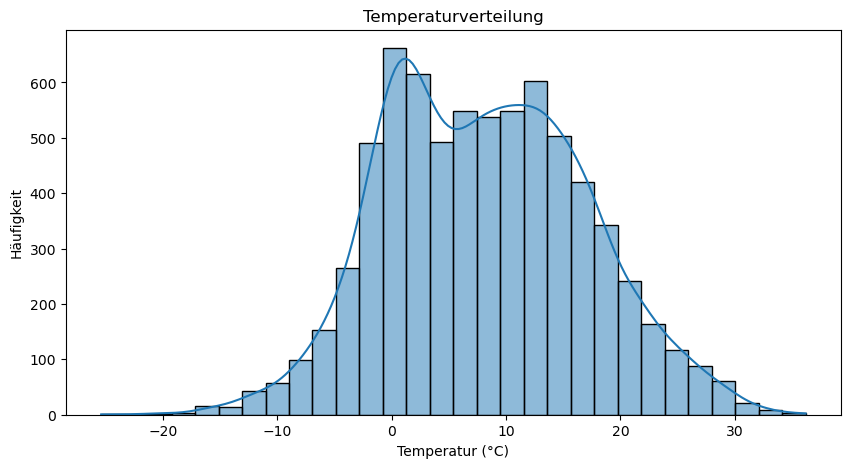

In [8]:
# 4. Explorative Datenanalyse (EDA)
print(df.describe())

# Visualisierung: Histogramm der Temperaturverteilung
plt.figure(figsize=(10, 5))
sns.histplot(df["TT_TER"], bins=30, kde=True)
plt.title("Temperaturverteilung")
plt.xlabel("Temperatur (°C)")
plt.ylabel("Häufigkeit")
plt.show()

## **Aufgabe : Erkennung und Entfernung von Ausreißern in Temperaturdaten**  

### **Identifikation und Bereinigung von Ausreißern mit der IQR-Methode**  
Bereinige die Temperaturwerte (`TT_TER`), indem du mögliche Ausreißer identifizierst und entfernst.

#### **Aufgaben:**  
1. Berechne den **Interquartilsabstand (IQR)** für die Temperaturwerte `TT_TER`:  
   - Bestimme das **1. Quartil (Q1)** und das **3. Quartil (Q3)**.  
   - Berechne die **IQR-Spanne**: `IQR = Q3 - Q1`.  
2. Bestimme die **untere und obere Grenze** für akzeptable Werte:  
   - **Untere Grenze**: `Q1 - 1.5 * IQR`  
   - **Obere Grenze**: `Q3 + 1.5 * IQR`  
3. Entferne Werte, die außerhalb dieser Grenzen liegen (potenzielle Ausreißer).  
4. Speichere den bereinigten DataFrame und überprüfe, ob Ausreißer erfolgreich entfernt wurden.  

#### **Hinweise:**  
- Die **IQR-Methode** ist eine bewährte Technik zur Identifikation von Ausreißern, da sie nicht empfindlich auf Extremwerte reagiert.  
- Falls du zu viele Werte verlierst, kannst du den Faktor `1.5` auf `3` erhöhen, um weniger strenge Grenzen zu setzen.  
- Falls du eine Visualisierung der Ausreißer möchtest, kannst du ein **Boxplot** mit `sns.boxplot(y=df['TT_TER'])` erstellen.  
- Falls `df` viele fehlende Werte enthält, überprüfe vorher mit `df.isnull().sum()`, ob die Bereinigung sinnvoll ist.  



In [10]:
Q1 = df["TT_TER"].quantile(0.25)
Q3 = df["TT_TER"].quantile(0.75)
IQR = Q3 - Q1

untere_grenze = Q1 - 1.5 * IQR
obere_grenze = Q3 + 1.5 * IQR

df = df[(df["TT_TER"] >= untere_grenze) & (df["TT_TER"] <= obere_grenze)]

## **Aufgabe: Zeitreihenanalyse der Temperaturwerte**  

### **Analyse der Temperaturverläufe mit gleitendem Durchschnitt**  
Untersuche die Entwicklung der Temperaturwerte über die Zeit und glätte die Kurve mit einem gleitenden Durchschnitt.

#### **Aufgaben:**  
1. **Setze die Datumswerte als Index**, um eine Zeitreihenanalyse durchführen zu können.  
2. **Berechne den gleitenden Durchschnitt** (`moving average`), um kurzfristige Schwankungen auszugleichen:  
   - Nutze eine Fenstergröße von **einem Monat** (30 Tage).  
3. **Visualisiere die Temperaturentwicklung** über die Zeit:  
   - Zeige die Originalwerte als transparente Linie (`alpha=0.5`).  
   - Zeichne den geglätteten Verlauf in einer gut sichtbaren Farbe (z. B. Rot).  
   - Ergänze eine **Legende, Titel und Achsenbeschriftungen** für eine klare Darstellung.  

#### **Hinweise:**  
- `df.set_index('MESS_DATUM', inplace=True)` stellt sicher, dass das Datum als Zeitindex genutzt wird.  
- `rolling(window=3*30).mean()` berechnet einen **30-Tage-Mittelwert**, um saisonale Schwankungen zu glätten.  
- Falls die Kurve noch zu stark schwankt, kannst du die Fenstergröße (`window`) vergrößern (z. B. auf 180 Tage für ein 6-monatiges Mittel).  

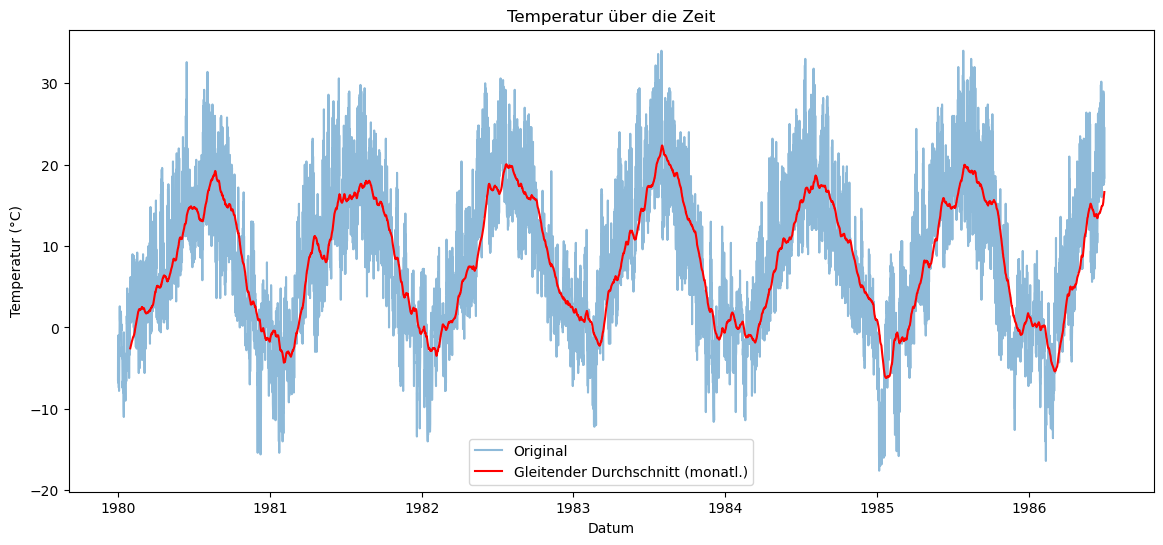

In [12]:
df.set_index("MESS_DATUM", inplace=True)

# Gleitender Durchschnitt für die Temperatur berechnen
df["TT_TER_MA"] = df["TT_TER"].rolling(window=3 * 30).mean()

# Temperatur über die Zeit visualisieren
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["TT_TER"], label="Original", alpha=0.5)
plt.plot(df.index, df["TT_TER_MA"], label="Gleitender Durchschnitt (monatl.)", color="red")
plt.legend()
plt.title("Temperatur über die Zeit")
plt.xlabel("Datum")
plt.ylabel("Temperatur (°C)")
plt.show()

## **Aufgabe: Saisonale Zerlegung der Temperaturwerte**  

### **Analyse der Zeitreihenkomponenten (Trend, Saisonalität, Residuen)**  
Untersuche die saisonalen Muster und langfristigen Trends in den Temperaturwerten (geglättete Temperaturwerte) mithilfe einer **saisonalen Zerlegung**.

#### **Aufgaben:**  
1. **Entferne fehlende Werte** aus der Zeitreihe, um Berechnungsprobleme zu vermeiden.  
2. **Führe eine saisonale Zerlegung der Temperaturwerte durch**:  
   - Verwende das **additive Modell** (`model="additive"`) für moderate saisonale Schwankungen.  
   - Setze die **Periode auf 1 Jahr (365*3, da 3 Werte pro Tag)**, um mehrjährige Trends und Saisonalitäten zu erfassen.  
3. **Visualisiere die Ergebnisse mit vier Diagrammen**:  
   - **Originale Zeitreihe** (geglättete Temperaturwerte).  
   - **Trend** (langfristige Entwicklung der Temperatur).  
   - **Saisonalität** (wiederkehrende Muster über Jahre hinweg).  
   - **Residuen (Rauschen)** (nicht erklärbare Variabilität).  
4. **Passe die X-Achse an**, um die Monats- und Jahresbeschriftung klar darzustellen.  

#### **Hinweise:**  
- `seasonal_decompose(df["TT_TER_MA"], model="additive", period=365*3)` zerlegt die Zeitreihe in ihre Hauptkomponenten.  
- Falls die Saisonalität sehr stark ist, könnte auch das **multiplikative Modell** (`model="multiplicative"`) sinnvoll sein.  
- Die **Trend-Komponente** zeigt die langfristige Entwicklung der Temperatur.  
- Die **Saisonalitäts-Komponente** zeigt wiederkehrende Muster (z. B. Sommer-Winter-Schwankungen).  
- Die **Residuen** zeigen unerklärliches Rauschen – starke Schwankungen können auf ungewöhnliche Ereignisse oder Datenprobleme hinweisen.  

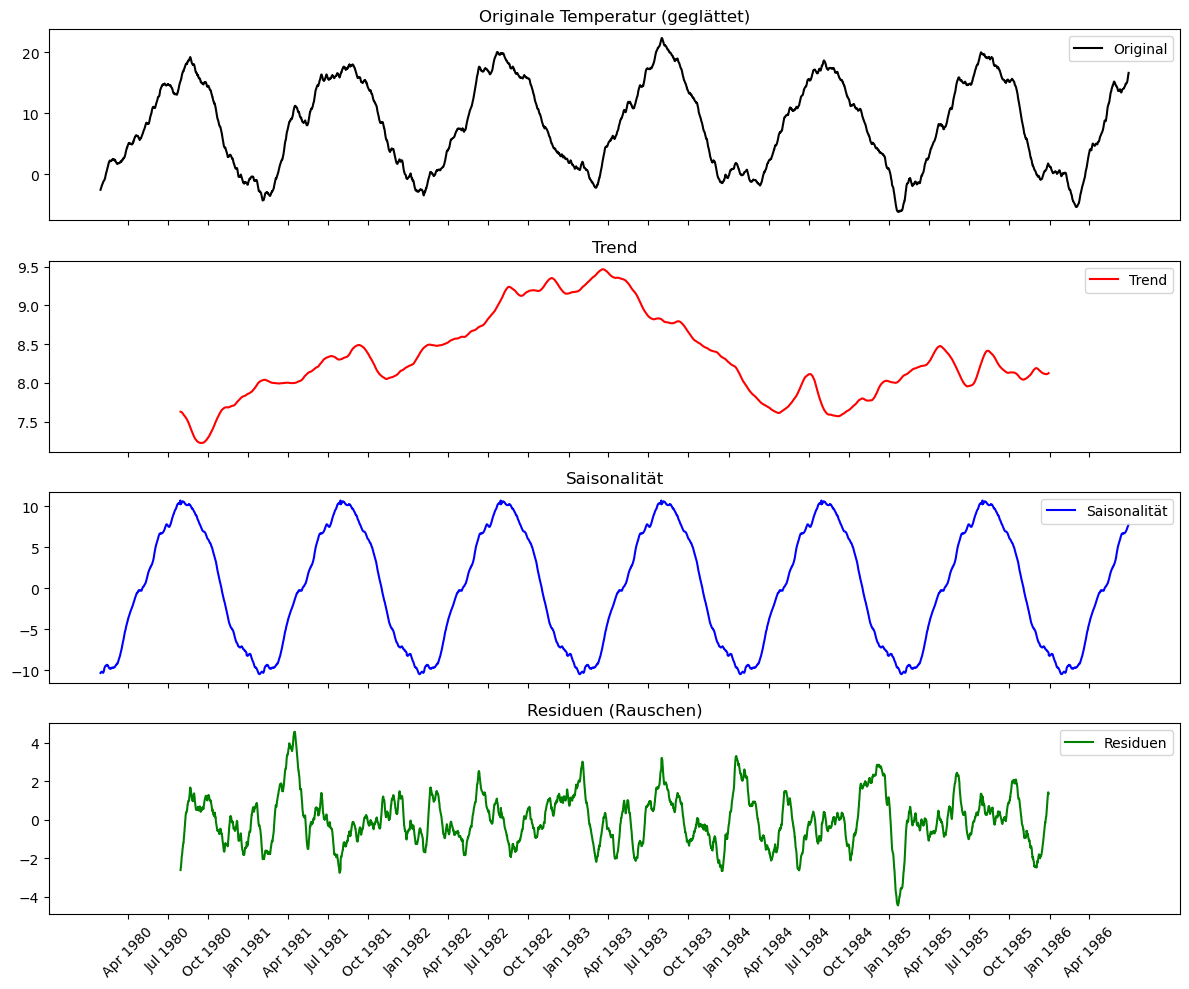

In [14]:
df = df.dropna()

# Saisonale Zerlegung der Temperatur mit einer Periode von 365 Tagen
result = seasonal_decompose(df["TT_TER_MA"], model="additive", period=365 * 3)

# Plot erstellen
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Originaldaten
axes[0].plot(df.index, df["TT_TER_MA"], label="Original", color="black")
axes[0].set_title("Originale Temperatur (geglättet)")
axes[0].legend()

# Trend
axes[1].plot(df.index, result.trend, label="Trend", color="red")
axes[1].set_title("Trend")
axes[1].legend()

# Saisonalität
axes[2].plot(df.index, result.seasonal, label="Saisonalität", color="blue")
axes[2].set_title("Saisonalität")
axes[2].legend()

# Residuen (Rauschen)
axes[3].plot(df.index, result.resid, label="Residuen", color="green")
axes[3].set_title("Residuen (Rauschen)")
axes[3].legend()

# X-Achse anpassen: Monatliche Labels setzen
xticks = pd.date_range(start=df.index.min(), end=df.index.max(), freq="QS")
axes[3].set_xticks(xticks)
axes[3].set_xticklabels(xticks.strftime("%b %Y"), rotation=45)

# Layout anpassen und anzeigen
plt.tight_layout()
plt.show()

Hier ist eine mögliche **Auswertung** der dargestellten Zeitreihenanalyse:

---

### 📊 **Zeitreihenanalyse der Temperaturdaten**

Die Abbildung zeigt eine Zerlegung der geglätteten Temperaturzeitreihe in ihre drei Hauptkomponenten: **Trend**, **Saisonalität** und **Residuen**.

---

#### 🔹 **Originale Temperatur (geglättet)**
Die geglättete Kurve der Originaldaten zeigt eine klare **saisonale Schwankung** mit regelmäßigen jährlichen Hoch- und Tiefpunkten. Darüber hinaus sind auch **mehrjährige Veränderungen** in der Mitteltemperatur erkennbar, die auf einen übergeordneten Trend hindeuten.

---

#### 🔹 **Trend**
Die Trendkomponente (rot dargestellt) zeigt eine **allmähliche Zunahme der mittleren Temperatur** von etwa 1980 bis 1984, gefolgt von einer leichten Abnahme. Diese Entwicklung könnte auf **langfristige klimatische Veränderungen** oder andere externe Einflussfaktoren hindeuten.

---

#### 🔹 **Saisonalität**
Die saisonale Komponente (blau) zeigt eine **stark regelmäßige, sinusförmige Struktur**, die typische saisonale Temperaturschwankungen widerspiegelt. Die Amplitude liegt bei etwa ±10 °C, was auf ausgeprägte jahreszeitliche Unterschiede hinweist. Diese Komponente bleibt über den gesamten Zeitraum **konstant**, was typisch für viele natürliche Zeitreihen ist.

---

#### 🔹 **Residuen (Rauschen)**
Die Residuen (grün) zeigen **kurzfristige Schwankungen**, die weder durch den langfristigen Trend noch durch die saisonalen Effekte erklärt werden können. Diese zufälligen Abweichungen bewegen sich meist im Bereich von ±3 °C. Einzelne Ausreißer deuten möglicherweise auf **extreme Wetterereignisse** oder **Messfehler** hin.

---

### 🧾 **Fazit**
Die Temperaturzeitreihe lässt sich erfolgreich in verständliche Komponenten zerlegen:

- Es liegt eine **ausgeprägte saisonale Struktur** vor.
- Ein **moderater, nicht-linearer Temperaturtrend** ist über mehrere Jahre hinweg zu erkennen.
- Die Residuen enthalten **stochastisches Rauschen** ohne systematische Muster.

Diese Zerlegung bietet eine solide Grundlage für **Prognosen**, **Anomalie-Erkennung** oder **klimatische Studien**.

---